## Методические указания по выполнению лабораторной работы №3

**Тема: Обнаружение объектов с использованием Faster R-CNN**

**Цель работы:** Ознакомиться с архитектурой Faster R-CNN и принципами двухэтапного обнаружения объектов.

**Задачи:**
- Изучить теоретические основы двухэтапного обнаружения объектов: роль RPN и классификационного этапа в Faster R-CNN.
- Загрузить предобученную модель Faster R-CNN.
- Ознакомиться с форматом аннотаций для обучения в задаче детекции.
- Визуализировать предсказания, проанализировать ошибки модели и провести исследование по поиску баланса FN/FP.

### 1. Теоретическая часть

В данной лабораторной работе мы познакомимся с задачей детекции на примере архитектуры [Faster R-CNN](https://arxiv.org/pdf/1506.01497), обученной на наборе данных [COCO](https://cocodataset.org/#home), а также с новым форматом данных для обучения нейро-сетевых моделей детекции. Для оценки модели воспользуемся набором данных [Pascal VOC 2007](http://host.robots.ox.ac.uk/pascal/VOC/).

**Перед тем, как приступать к выполнению практической части, ознакомьтесь с первоисточниками используемых компонентов, а также документацией по [ссылке](https://pytorch.org/vision/master/models/faster_rcnn.html), включающей подробности работы с моделью и новым форматом данных, сэмплы кода.**

#### 1.1 Архитектура Faster R-CNN

Существует два основных подхода к обнаружению объектов:
Двухстадийные модели – более точные, но медленные.
Одностадийные модели – быстрые, но менее точные.

Faster R-CNN — это двухэтапная модель детекции объектов. В отличие от ResNeXt, Faster R-CNN не просто классифицирует изображение, а находит на нём несколько объектов, предсказывает bounding boxes и присваивает метки классам. Она состоит из следующих компонентов:

1. Backbone (ResNet/VGG/MobileNet) – извлекает признаки из изображения.
2. Region Proposal Network (RPN) – предлагает области, где могут находиться объекты.
3. ROI Pooling + Fully Connected Layers – классифицирует объекты и уточняет bounding boxes.
4. Non-Maximum Suppression (NMS) – убирает дублирующиеся предсказания.


В предыдущих лабораторных работах мы познакомились с классификацией изображений, где модель предсказывает единственный класс для всего изображения. Однако во многих задачах компьютерного зрения классификация недостаточна. Например, когда на одном изображении присутствуют несколько объектов разных классов необходимо не только определить, что изображено, но и где это находится.

Faster R-CNN –  модель, которая также решает задачу обнаружения объектов, добавляя к классификации локализацию. 

#### 1.2 Формат данных для задачи детекции

Faster R-CNN требует разметки изображений, помимо классов включающей в себя и координаты bounding box по оси x, y.
Ознакомьтесь с форматом набора данных Pascal VOC, скачайте аннотации набора данных и изучите структуру **.xml** файлов в папке Annotations по [ссылке](http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtestnoimgs_06-Nov-2007.tar).

#### 1.3 Оценка качества

Помимо известных вам инструментов оценить качество работы детектора могут помочь:

Confidence Score - значение, указывающее на уверенность модели в том, что на данном месте изображения находится объект. Модель предсказывает этот параметр для каждого предсказанного bounding box. Чем выше confidence score, тем более уверена модель в своём предсказании.

Фильтрация предсказаний - модель может предсказать много объектов, но не все из них будут точными. Чтобы уменьшить количество ложных срабатываний (False Positives), применяется фильтр предсказаний, используя confidence threshold. Если confidence score меньше заданного порога - предсказание отбрасывается.


### 2. Практическая часть

#### 2.1 Подготовка окружения

Установите зависимости и библиотеки:

In [9]:
# импорт пакетов
import torch
import torchvision
from torchvision import transforms
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import os
import json
from collections import defaultdict

#### 2.2 Подготовка модели

Загрузите предобученную модель, определите устройство, переведите модель в режим инференса:

In [ ]:
# Загружаем предобученную модель Faster R-CNN
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()  # Переводим в режим инференса

# Определяем устройство (GPU если доступно, иначе CPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
print(f"Модель загружена на устройство: {device}")

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Модель загружена на устройство: cpu


#### 2.3 Загрузка и предобработка изображений


Затем импортируйте датасет из соответствующих пакетов PyTorch и определите метод трансформации данных для подачи в модель. Он понадобится позже для преобразования изображений при прямом проходе через модель чтобы получить предсказания:

In [ ]:
# загрузка датасета
dataset = torchvision.datasets.CocoDetection(
    root='./data/coco/val2017',
    annFile='./data/coco/annotations/instances_val2017.json',
    transform=transforms.ToTensor()
)

print(f"Загружено {len(dataset)} изображений")

# Метод трансформации для инференса
def transform_image(image):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    return transform(image).unsqueeze(0)  # Добавляем batch dimension

loading annotations into memory...
Done (t=0.21s)
creating index...
index created!
Загружено 5000 изображений


#### 2.4 Объявление методов для работы с данными

Далее необходимо создать методы препроцессинга: метод чтения файла аннотации для возврата numpy-объекта содержащего bounding boxes, и метод отрисовки истиных и прогнозных bounding boxes на изображении для визуализации полученных результатов.

In [ ]:
def draw_predictions(image, boxes, labels, scores, color="blue"):
    draw = ImageDraw.Draw(image)
    for box, label, score in zip(boxes, labels, scores):
        xmin, ymin, xmax, ymax = map(int, box)
        draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=3)
        
        # Получаем название класса из COCO
        class_name = coco_classes.get(label, f"Class {label}")
        draw.text((xmin, ymin-20), f"{class_name} ({score:.2f})", fill=color)
    return image

def draw_ground_truth(image, annotations, color="green"):
    draw = ImageDraw.Draw(image)
    for ann in annotations:
        if 'bbox' in ann:
            x, y, w, h = ann['bbox']
            xmin, ymin, xmax, ymax = int(x), int(y), int(x + w), int(y + h)
            draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=2)
            
            # Получаем название класса из COCO
            class_name = coco_classes.get(ann['category_id'], f"Class {ann['category_id']}")
            draw.text((xmin, ymin), f"GT: {class_name}", fill=color)
    return image

#### 2.5 Анализ False Positives / False Negatives

Для измерения того, насколько хорошо bounding box предсказан, применяется параметр IoU (Intersection over Union) между двумя bounding boxes. Чем он выше, тем точнее предсказание. Для его оценки опишем следующий метод, принимающий два np.array-объекта (прогнозные и истинные координаты):

In [ ]:
def calculate_iou(pred_box, gt_box):
    """Calculate Intersection over Union"""
    x1, y1, x2, y2 = pred_box
    x1g, y1g, x2g, y2g = gt_box
    
    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def evaluate_predictions(pred_boxes, gt_boxes, iou_threshold=0.5):
    """Evaluate predictions and count TP, FP, FN"""
    if len(pred_boxes) == 0:
        return 0, 0, len(gt_boxes)  # Все GT становятся FN
    
    if len(gt_boxes) == 0:
        return 0, len(pred_boxes), 0  # Все predictions становятся FP
    
    tp = 0
    fp = 0
    matched_gt = set()
    
    for i, pred_box in enumerate(pred_boxes):
        max_iou = 0
        best_gt_idx = -1
        
        for j, gt_box in enumerate(gt_boxes):
            iou = calculate_iou(pred_box, gt_box)
            if iou > max_iou:
                max_iou = iou
                best_gt_idx = j
        
        if max_iou >= iou_threshold and best_gt_idx not in matched_gt:
            tp += 1
            matched_gt.add(best_gt_idx)
        else:
            fp += 1
    
    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn

# COCO classes mapping
coco_classes = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
    11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench'
}

#### 2.6 Оценка модели и визуализация результатов

Выполните прямой проход нескольких изображений через модель. Для этого необходимо загрузить изображения и аннотации, применить преобразование изображений в тензор. Затем получите выходы модели:


=== Анализ первых 5 изображений ===

Обработка изображения 1/5


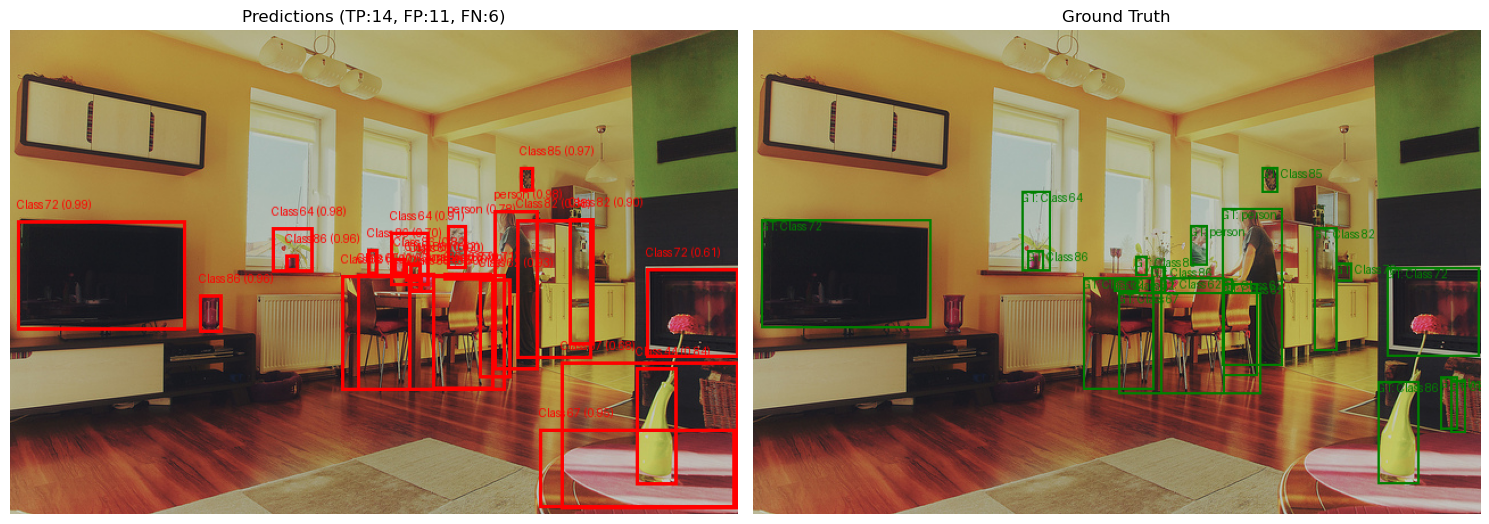

  Predictions: 25, GT: 20
  TP: 14, FP: 11, FN: 6

Обработка изображения 2/5


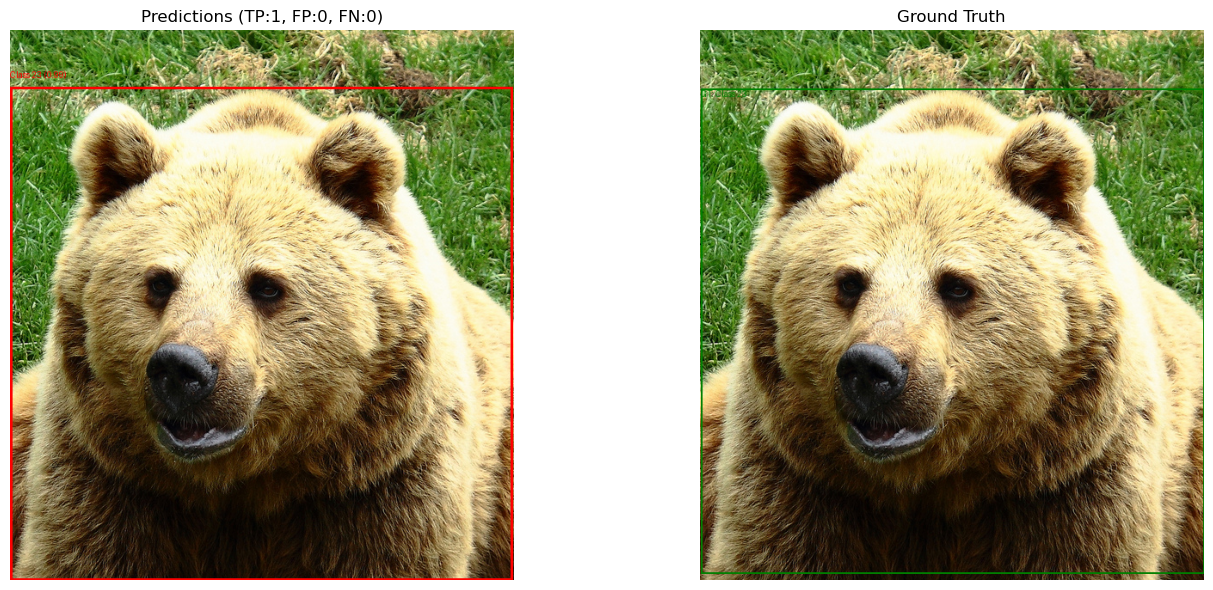

  Predictions: 1, GT: 1
  TP: 1, FP: 0, FN: 0

Обработка изображения 3/5


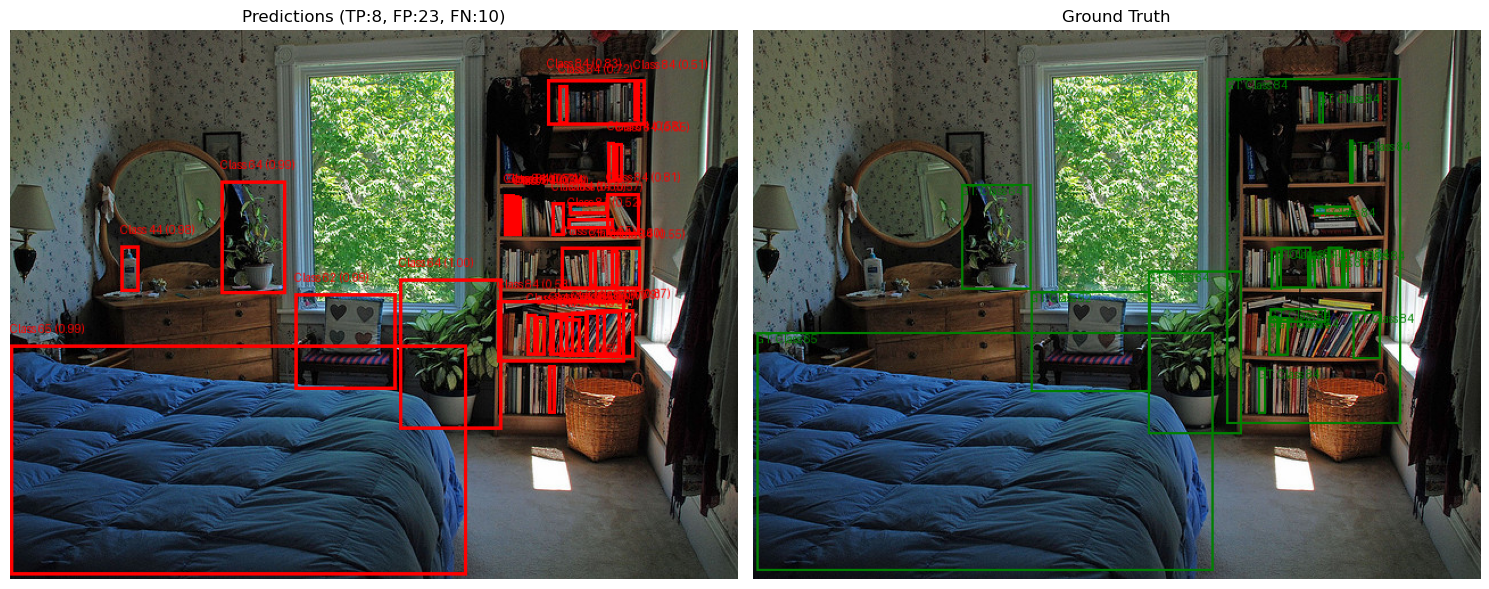

  Predictions: 31, GT: 18
  TP: 8, FP: 23, FN: 10

Обработка изображения 4/5


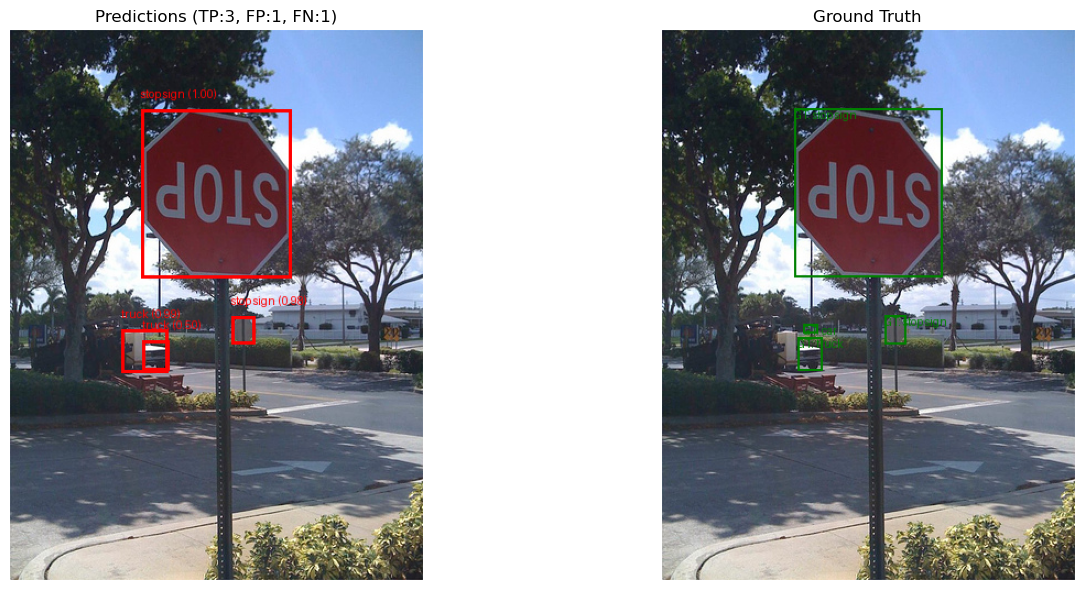

  Predictions: 4, GT: 4
  TP: 3, FP: 1, FN: 1

Обработка изображения 5/5


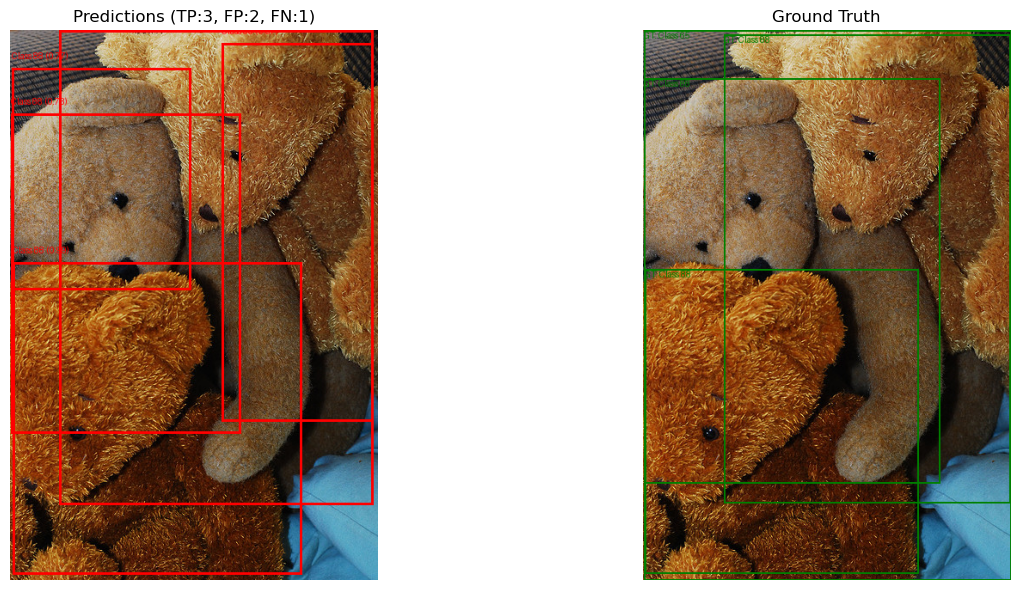

  Predictions: 5, GT: 4
  TP: 3, FP: 2, FN: 1


In [ ]:
def process_single_image(image_tensor, annotations, confidence_threshold=0.5):
    """Process single image and return predictions"""
    with torch.no_grad():
        prediction = model([image_tensor.to(device)])[0]
    
    # Фильтруем предсказания по порогу уверенности
    mask = prediction['scores'] > confidence_threshold
    pred_boxes = prediction['boxes'][mask].cpu().numpy()
    pred_labels = prediction['labels'][mask].cpu().numpy()
    pred_scores = prediction['scores'][mask].cpu().numpy()
    
    # Преобразуем GT bboxes в формат [xmin, ymin, xmax, ymax]
    gt_boxes = []
    for ann in annotations:
        if 'bbox' in ann:
            x, y, w, h = ann['bbox']
            gt_boxes.append([x, y, x + w, y + h])
    
    return pred_boxes, pred_labels, pred_scores, gt_boxes

# Выбираем N изображений для анализа
N = 5
results = []

print("\n=== Анализ первых 5 изображений ===")
for i in range(min(N, len(dataset))):
    print(f"\nОбработка изображения {i+1}/{N}")
    
    # Загружаем изображение и аннотации
    image_tensor, annotations = dataset[i]
    image_pil = transforms.ToPILImage()(image_tensor)
    
    # Выполняем предсказание
    confidence_threshold = 0.5
    pred_boxes, pred_labels, pred_scores, gt_boxes = process_single_image(
        image_tensor, annotations, confidence_threshold
    )
    
    # Оцениваем качество предсказаний
    tp, fp, fn = evaluate_predictions(pred_boxes, gt_boxes)
    
    # Визуализируем результаты
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Изображение с предсказаниями
    img_pred = image_pil.copy()
    img_pred = draw_predictions(img_pred, pred_boxes, pred_labels, pred_scores, "red")
    ax1.imshow(img_pred)
    ax1.set_title(f'Predictions (TP:{tp}, FP:{fp}, FN:{fn})')
    ax1.axis('off')
    
    # Изображение с ground truth
    img_gt = image_pil.copy()
    img_gt = draw_ground_truth(img_gt, annotations, "green")
    ax2.imshow(img_gt)
    ax2.set_title('Ground Truth')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Сохраняем результаты
    results.append({
        'image_id': i,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'num_predictions': len(pred_boxes),
        'num_gt': len(gt_boxes)
    })
    
    print(f"  Predictions: {len(pred_boxes)}, GT: {len(gt_boxes)}")
    print(f"  TP: {tp}, FP: {fp}, FN: {fn}")

#### 2.7 Поиск оптимальной конфигурации 

Проанализируйте полученные результаты с выбранным значением фильтрации предсказаний. Проведите исследование с целью поиска оптимального порога и баланса FN/FP. Обоснуйте полученные результаты:


=== Исследование оптимального порога уверенности ===
Threshold 0.1: Predictions=68, TP=15, FP=53, FN=5
Threshold 0.2: Predictions=48, TP=15, FP=33, FN=5
Threshold 0.3: Predictions=36, TP=14, FP=22, FN=6
Threshold 0.4: Predictions=27, TP=14, FP=13, FN=6
Threshold 0.5: Predictions=25, TP=14, FP=11, FN=6
Threshold 0.6: Predictions=23, TP=14, FP=9, FN=6
Threshold 0.7: Predictions=19, TP=12, FP=7, FN=8
Threshold 0.8: Predictions=17, TP=11, FP=6, FN=9
Threshold 0.9: Predictions=11, TP=7, FP=4, FN=13


/var/folders/38/l4hfq4694136377jqp7rr75c0000gn/T/ipykernel_43717/2466708662.py:66: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "co-" (-> color='c'). The keyword argument will take precedence.
  ax3.plot(thresholds_list, predictions_list, 'co-', linewidth=2, color='purple')  # Исправлено здесь


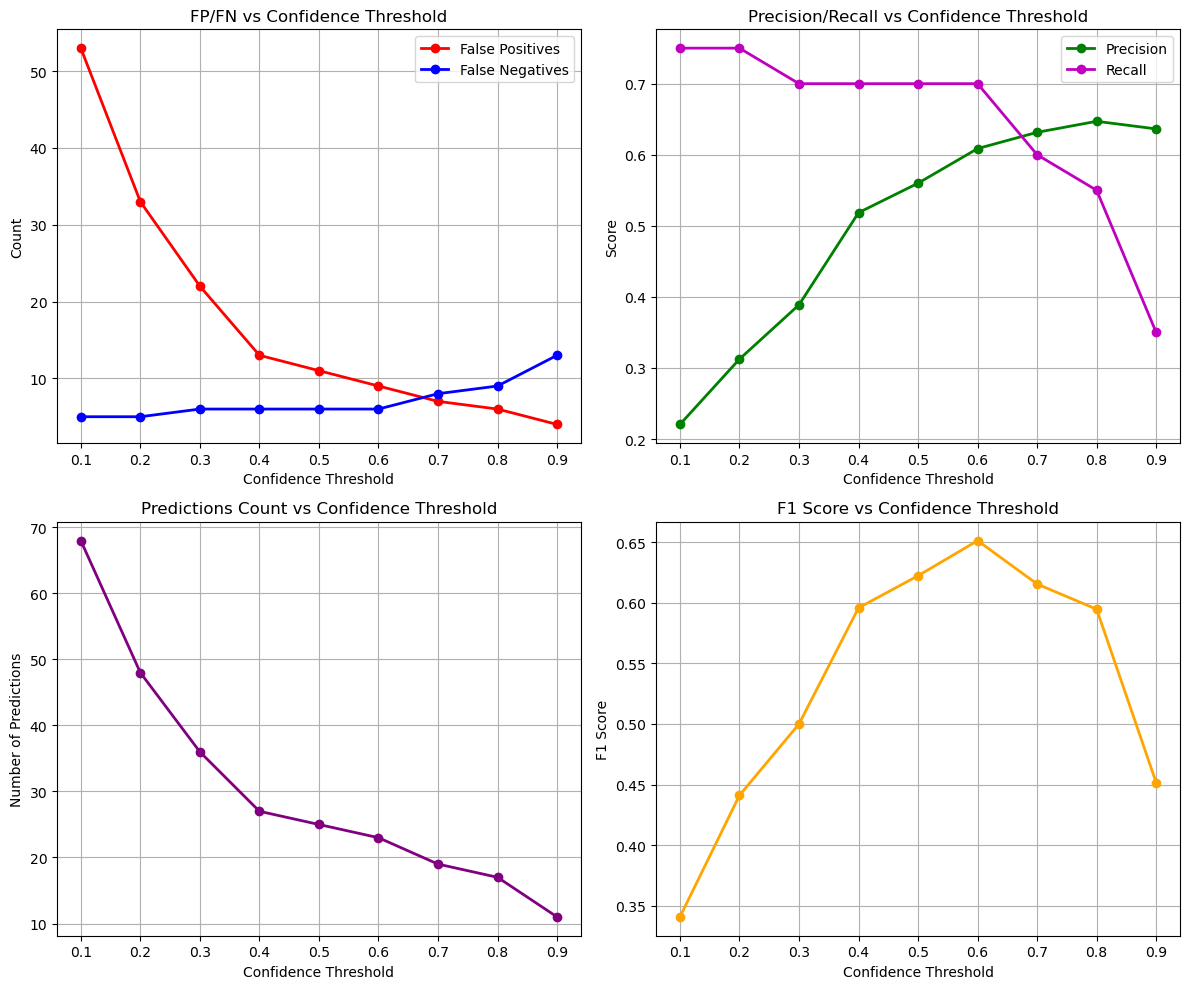


=== РЕЗУЛЬТАТЫ ИССЛЕДОВАНИЯ ===
Оптимальный порог уверенности: 0.6
Максимальный F1-score: 0.651
При этом пороге:
  - Precision: 0.609
  - Recall: 0.700
  - False Positives: 9
  - False Negatives: 6

=== Демонстрация с оптимальным порогом (0.6) ===


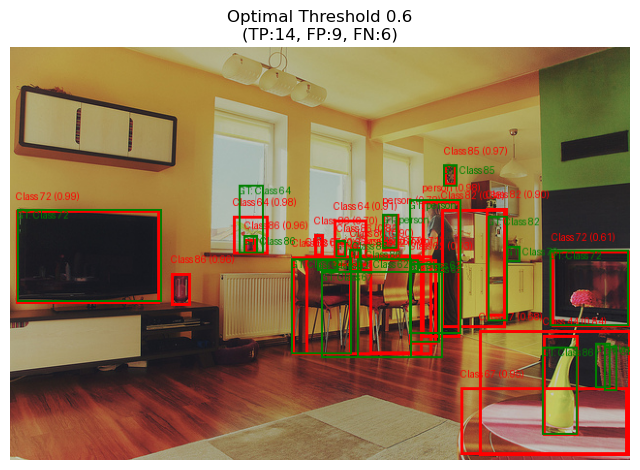


Анализ завершен!


In [ ]:
print("\n=== Исследование оптимального порога уверенности ===")

# Выбираем одно изображение для детального анализа
test_idx = 0
image_tensor, annotations = dataset[test_idx]
gt_boxes = []
for ann in annotations:
    if 'bbox' in ann:
        x, y, w, h = ann['bbox']
        gt_boxes.append([x, y, x + w, y + h])

# Тестируем разные пороги
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results = []

for threshold in thresholds:
    pred_boxes, pred_labels, pred_scores, _ = process_single_image(
        image_tensor, annotations, threshold
    )
    
    tp, fp, fn = evaluate_predictions(pred_boxes, gt_boxes)
    
    threshold_results.append({
        'threshold': threshold,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'num_predictions': len(pred_boxes),
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'recall': tp / (tp + fn) if (tp + fn) > 0 else 0
    })
    
    print(f"Threshold {threshold:.1f}: Predictions={len(pred_boxes):2d}, TP={tp}, FP={fp}, FN={fn}")

# Визуализируем результаты исследования порогов
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# График FP/FN
thresholds_list = [r['threshold'] for r in threshold_results]
fp_list = [r['fp'] for r in threshold_results]
fn_list = [r['fn'] for r in threshold_results]

ax1.plot(thresholds_list, fp_list, 'ro-', label='False Positives', linewidth=2)
ax1.plot(thresholds_list, fn_list, 'bo-', label='False Negatives', linewidth=2)
ax1.set_xlabel('Confidence Threshold')
ax1.set_ylabel('Count')
ax1.set_title('FP/FN vs Confidence Threshold')
ax1.legend()
ax1.grid(True)

# График Precision/Recall
precision_list = [r['precision'] for r in threshold_results]
recall_list = [r['recall'] for r in threshold_results]

ax2.plot(thresholds_list, precision_list, 'go-', label='Precision', linewidth=2)
ax2.plot(thresholds_list, recall_list, 'mo-', label='Recall', linewidth=2)
ax2.set_xlabel('Confidence Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Precision/Recall vs Confidence Threshold')
ax2.legend()
ax2.grid(True)

# График количества предсказаний
predictions_list = [r['num_predictions'] for r in threshold_results]
ax3.plot(thresholds_list, predictions_list, 'co-', linewidth=2, color='purple')  # Исправлено здесь
ax3.set_xlabel('Confidence Threshold')
ax3.set_ylabel('Number of Predictions')
ax3.set_title('Predictions Count vs Confidence Threshold')
ax3.grid(True)

# График F1-score
f1_scores = []
for r in threshold_results:
    precision = r['precision']
    recall = r['recall']
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    f1_scores.append(f1)

ax4.plot(thresholds_list, f1_scores, 'o-', linewidth=2, color='orange')
ax4.set_xlabel('Confidence Threshold')
ax4.set_ylabel('F1 Score')
ax4.set_title('F1 Score vs Confidence Threshold')
ax4.grid(True)

plt.tight_layout()
plt.show()

# Анализ результатов
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]

print(f"\n=== РЕЗУЛЬТАТЫ ИССЛЕДОВАНИЯ ===")
print(f"Оптимальный порог уверенности: {best_threshold:.1f}")
print(f"Максимальный F1-score: {best_f1:.3f}")
print(f"При этом пороге:")
print(f"  - Precision: {precision_list[best_f1_idx]:.3f}")
print(f"  - Recall: {recall_list[best_f1_idx]:.3f}")
print(f"  - False Positives: {fp_list[best_f1_idx]}")
print(f"  - False Negatives: {fn_list[best_f1_idx]}")

# Демонстрация работы с оптимальным порогом
print(f"\n=== Демонстрация с оптимальным порогом ({best_threshold:.1f}) ===")
optimal_boxes, optimal_labels, optimal_scores, _ = process_single_image(
    image_tensor, annotations, best_threshold
)

tp_opt, fp_opt, fn_opt = evaluate_predictions(optimal_boxes, gt_boxes)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
img_optimal = transforms.ToPILImage()(image_tensor)
img_optimal = draw_predictions(img_optimal, optimal_boxes, optimal_labels, optimal_scores, "red")
img_optimal = draw_ground_truth(img_optimal, annotations, "green")
ax.imshow(img_optimal)
ax.set_title(f'Optimal Threshold {best_threshold:.1f}\n(TP:{tp_opt}, FP:{fp_opt}, FN:{fn_opt})')
ax.axis('off')
plt.show()

print("\nАнализ завершен!")